# Model 1 — Logistic Regression

A linear model: it fits one coefficient per feature and adds them up. It cannot represent interactions between features on its own, so it sets the floor that the tree models have to beat.

**This notebook never loads the test set.** Hyperparameters are chosen by an inner cross-validation, performance is estimated by an outer cross-validation, and the decision threshold is chosen on out-of-fold predictions. Everything here is derived from `train.csv` alone. The test set is opened once, in notebook 08, after the winning model has already been picked.

Why nested cross-validation: if you tune on 5 folds and then report the best score those same 5 folds produced, you are reporting the maximum of a noisy search, which is optimistically biased. The outer loop fixes that — each outer fold is scored by a search that never saw it.

In [1]:
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, GridSearchCV, RandomizedSearchCV,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import (precision_recall_curve, average_precision_score, roc_auc_score,
                             f1_score, recall_score, precision_score)

palette = ['#2B5C8F', '#E05A47']

## 1. Load the training set

In [2]:
# agent is an ID, so it is read as text (see 02_preprocessing)
train = pd.read_csv('../data/processed/train.csv', dtype={'agent': str})
X_train, y_train = train.drop(columns=['is_canceled']), train['is_canceled']

print('train:', X_train.shape)
print(f'cancellation rate: {y_train.mean():.4f}')
print('test.csv is deliberately not loaded in this notebook')

train: (67975, 25)
cancellation rate: 0.2775
test.csv is deliberately not loaded in this notebook


## 2. The pipeline

In [3]:
categorical_cols = X_train.select_dtypes(exclude='number').columns
numeric_cols = X_train.select_dtypes(include='number').columns

preprocess = ColumnTransformer([
    # this model is sensitive to feature scale, so numeric columns are standardised
    ('num', StandardScaler(), numeric_cols),
    # same encoding as every other model: countries/agents with fewer than 100 bookings share one column
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=100), categorical_cols),
], verbose_feature_names_out=False)

pipe = Pipeline([('prep', preprocess),
                 ('model', LogisticRegression(max_iter=1000, random_state=42))])
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{tran

`n_jobs` on the estimator is left at 1 wherever the model supports it: the hyperparameter search below is what runs in parallel, and letting both compete for the same cores makes the nested loop dramatically slower without changing a single result.

The encoder is a step *inside* the pipeline, not something applied to the frame beforehand. That is what makes the nested loop below honest: every time the pipeline is fitted, the encoder is refitted on just that fold's training rows, so no fold is ever encoded using counts drawn from the rows it is scored on.

## 3. The search space

In [4]:
param_grid = {
    # regularisation strength: strong (0.01) through to weak (10)
    'model__C': [0.01, 0.1, 1, 10],
}

# the 5 outer folds are the same folds every model in this project uses
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# the inner loop does the tuning, on 3 folds to keep the nested cost affordable
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def make_search(cv):
    """A hyperparameter search over the grid above, scored on PR-AUC."""
    return GridSearchCV(pipe, param_grid, scoring='average_precision', cv=cv, n_jobs=-1)

param_grid

{'model__C': [0.01, 0.1, 1, 10]}

Four settings is a small enough grid to search exhaustively.

PR-AUC (`average_precision`) is the search metric throughout, for the reasons argued in 02: with 27.7% positives, accuracy rewards a model for being right about the majority class, and PR-AUC does not.

## 4. Nested cross-validation — the unbiased estimate

In [5]:
# Outer loop: 5 folds. For each, a full hyperparameter search runs on the other 4 folds
# and the resulting model is scored once on the held-out fold it never saw.
start = time.time()
nested = cross_val_score(make_search(inner_cv), X_train, y_train,
                         cv=outer_cv, scoring='average_precision', n_jobs=1)
nested_seconds = time.time() - start

print('outer fold scores:', np.round(nested, 4))
print(f'nested CV PR-AUC: {nested.mean():.4f} +/- {nested.std():.4f}')
print(f'took {nested_seconds:.0f} s')

outer fold scores: [0.6633 0.6472 0.6341 0.6432 0.6473]
nested CV PR-AUC: 0.6470 +/- 0.0095
took 14 s


This is the number that goes into the model comparison. It answers "how well does *this whole procedure* — search included — generalise", which is the question a model-selection step actually needs answered.

## 5. Fit the final model on the whole training set

In [6]:
# Nested CV estimates how well the procedure generalises; it does not hand back a model.
# To get one, the same search is run once more on the full training set.
start = time.time()
search = make_search(inner_cv)
search.fit(X_train, y_train)
fit_seconds = time.time() - start

print('chosen parameters:', search.best_params_)
print(f'inner-CV PR-AUC at those parameters: {search.best_score_:.4f}')
print(f'took {fit_seconds:.0f} s')

chosen parameters: {'model__C': 1}
inner-CV PR-AUC at those parameters: 0.6464
took 3 s


In [7]:
results = pd.DataFrame(search.cv_results_)
cols = [c for c in results.columns if c.startswith('param_')] + ['mean_test_score', 'std_test_score']
results[cols].sort_values('mean_test_score', ascending=False).round(4)

,param_model__C,mean_test_score,std_test_score
2,1.00,0.6464,0.0085
3,10.00,0.6464,0.0086
1,0.10,0.6460,0.0084
0,0.01,0.6403,0.0082


`best_score_` above is the inner-CV score at the chosen settings. It is reported here only to show what the search saw — it is *not* the number used to compare models, because it is the maximum of a search and therefore optimistic. Section 4's nested score is the one that goes forward.

## 6. Choosing the decision threshold

F1 at the default 0.50 threshold: 0.5412
chosen threshold: 0.3033  ->  F1 0.6269, precision 0.5496, recall 0.7295
out-of-fold PR-AUC: 0.6466


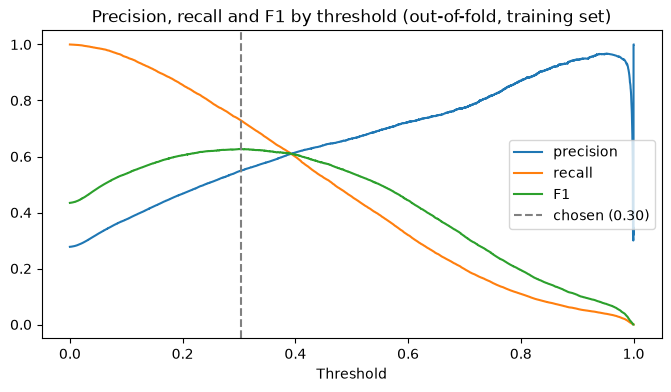

In [8]:
# out-of-fold probabilities on the training set: each booking scored by a model that did not train on it
oof_proba = cross_val_predict(search.best_estimator_, X_train, y_train,
                              cv=outer_cv, method='predict_proba', n_jobs=-1)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-12)
best = int(np.argmax(f1[:-1]))
threshold = float(thresholds[best])

print(f'F1 at the default 0.50 threshold: {f1_score(y_train, oof_proba >= 0.5):.4f}')
print(f'chosen threshold: {threshold:.4f}  ->  F1 {f1[best]:.4f}, '
      f'precision {precision[best]:.4f}, recall {recall[best]:.4f}')
print(f'out-of-fold PR-AUC: {average_precision_score(y_train, oof_proba):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision[:-1], label='precision')
plt.plot(thresholds, recall[:-1], label='recall')
plt.plot(thresholds, f1[:-1], label='F1')
plt.axvline(threshold, color='grey', linestyle='--', label=f'chosen ({threshold:.2f})')
plt.xlabel('Threshold')
plt.title('Precision, recall and F1 by threshold (out-of-fold, training set)')
plt.legend()
plt.show()

The threshold is picked on out-of-fold training predictions, never on the test set. It is carried forward to notebook 08 as a fixed number, so the final test evaluation has nothing left to tune.

## 7. Save what notebook 08 needs

In [9]:
row = {
    'model': 'Logistic Regression',
    'nested_cv_pr_auc_mean': nested.mean(),
    'nested_cv_pr_auc_std': nested.std(),
    'inner_cv_pr_auc': search.best_score_,
    'oof_pr_auc': average_precision_score(y_train, oof_proba),
    'oof_f1_at_0.5': f1_score(y_train, oof_proba >= 0.5),
    'threshold': threshold,
    'oof_f1_at_threshold': f1[best],
    'best_params': json.dumps({k: str(v) for k, v in search.best_params_.items()}),
    'nested_seconds': nested_seconds,
    'fit_seconds': fit_seconds,
}
Path('../reports/results').mkdir(parents=True, exist_ok=True)
pd.DataFrame([row]).round(4).to_csv('../reports/results/logistic_regression.csv', index=False)
pd.DataFrame([row]).round(4).T

,0
model,Logistic Regression
nested_cv_pr_auc_mean,0.647
nested_cv_pr_auc_std,0.0095
inner_cv_pr_auc,0.6464
oof_pr_auc,0.6466
oof_f1_at_0.5,0.5412
threshold,0.3033
oof_f1_at_threshold,0.6269
best_params,"{""model__C"": ""1""}"
nested_seconds,14.2728


## 8. Export the trained model

The fitted pipeline is saved to `models/logistic_regression.joblib`. It holds the encoder **and** the Logistic Regression together, so it can be loaded later and used on new bookings straight away, with no retraining:

```python
model = joblib.load('../models/logistic_regression.joblib')
model.predict_proba(new_bookings)[:, 1]   # probability of cancellation
```

In [10]:
import joblib

Path('../models').mkdir(exist_ok=True)
joblib.dump(search.best_estimator_, '../models/logistic_regression.joblib', compress=3)

size_mb = Path('../models/logistic_regression.joblib').stat().st_size / 1e6
print(f'saved models/logistic_regression.joblib ({size_mb:.1f} MB)')

saved models/logistic_regression.joblib (0.0 MB)


## Conclusion

Nested cross-validation puts Logistic Regression at **0.6470 PR-AUC** (spread 0.0095 across the five outer folds), on the settings `{'model__C': '1'}`. That is rank 5 of the five models compared in notebook 08.

The inner-CV score at those settings was 0.6464, slightly *below* the nested estimate (-0.0006). A positive gap here would be the winner's curse — the search reporting its own maximum as if it were an unbiased estimate. At this size the difference is not meaningful either way, which is itself worth recording: on this dataset the grids are flat enough that tuning does not buy much room to overfit.

The out-of-fold threshold is 0.3033, well below 0.5, and it lifts out-of-fold F1 from 0.5412 to 0.6269. That threshold is carried into notebook 08 as a fixed number.

This is the floor the other models have to beat, and it is a meaningful floor: a linear model with no interaction terms still ranks bookings far better than chance. What it cannot do is capture the combinations — a long lead time *and* a non-refundable deposit *and* no special requests — that the tree models exploit.

No test-set number appears anywhere in this notebook by design. The single test evaluation happens in notebook 08, once, on the model selected from the table above.